# Exercise 1: Implement kmeans clustering

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

In [2]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

### Load Iris dataset using sklearn

In [3]:
from sklearn.datasets import load_iris
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)

In [4]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [5]:
X = df[['sepal length (cm)','sepal width (cm)']].values

In [6]:
X_scaled = scaler.fit_transform(X)

### Apply K-Means clustering with a fixed number of clusters (k=3).


In [7]:
kmeans = KMeans(n_clusters=5,init='k-means++',random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

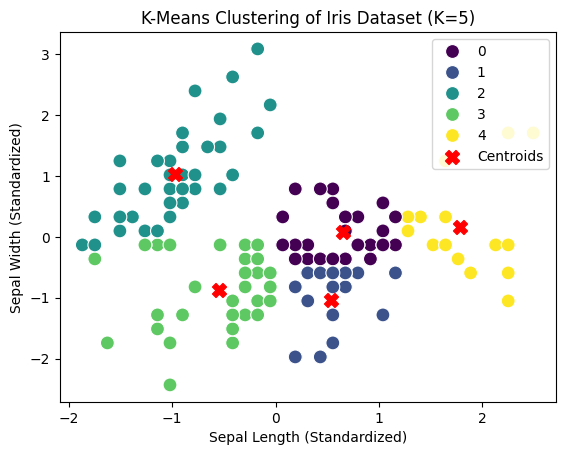

In [8]:
sns.scatterplot(x=X_scaled[:,0],y=X_scaled[:,1],hue=y_kmeans,palette='viridis',s=100)
plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1],s=100,c='red',marker='X',label='Centroids')
plt.xlabel("Sepal Length (Standardized)")
plt.ylabel("Sepal Width (Standardized)")
plt.title("K-Means Clustering of Iris Dataset (K=5)")
plt.legend()
plt.show()

## 2. K-Means Clustering Elbow Method

The Elbow Method is a technique used to determine the optimal number of clusters (k) in K-Means clustering. It does this by analyzing the Within-CLuster Sim of Squares (WCSS), which measures the total varience within each cluster.

In [9]:
wcss= []
k_values = range(1,11)
for k in k_values:
  kmeans = KMeans(n_clusters=k,random_state=42,n_init=10)
  kmeans.fit(X)
  wcss.append(kmeans.inertia_)

In [10]:
from kneed import KneeLocator
knee_locator = KneeLocator(k_values,wcss,curve='convex',direction='decreasing')
optimal_k = knee_locator.elbow

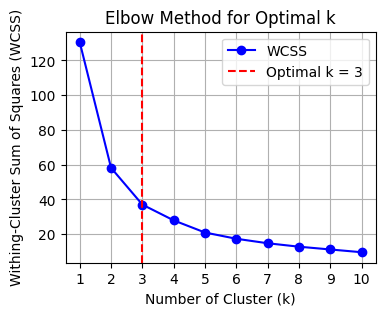

Optimal number of clusters (k) found by Elbow Method: 3


In [11]:
plt.figure(figsize=(4,3))
plt.plot(k_values,wcss,marker='o',linestyle='-',color='b',label='WCSS')
plt.axvline(optimal_k,color='r',linestyle='--',label=f"Optimal k = {optimal_k}")
plt.xlabel("Number of Cluster (k)")
plt.ylabel("Withing-Cluster Sum of Squares (WCSS)")
plt.title("Elbow Method for Optimal k")
plt.xticks(k_values)
plt.legend()
plt.grid(True)
plt.show()
print(f"Optimal number of clusters (k) found by Elbow Method: {optimal_k}")


# Step 1: Collect the markdown

In [12]:
X = np.array([[2,3,4],[3,5,6],[5,8,9],[6,9,11],[7,10,13]])

In [13]:
X

array([[ 2,  3,  4],
       [ 3,  5,  6],
       [ 5,  8,  9],
       [ 6,  9, 11],
       [ 7, 10, 13]])

# Step 2: Computer the Mean

In [14]:
x1,x2,x3 = X[:,0].mean(),X[:,1].mean(),X[:,2].mean()

# Step 3: Center the data

In [15]:
v1 = list(X[:,0]) - x1
v2 = list(X[:,1]) - x2
v3 = list(X[:,2]) - x3

In [16]:
X_centered = np.array([v1,v2,v3])

In [17]:
X_centered = X_centered.T

In [18]:
X_centered

array([[-2.6, -4. , -4.6],
       [-1.6, -2. , -2.6],
       [ 0.4,  1. ,  0.4],
       [ 1.4,  2. ,  2.4],
       [ 2.4,  3. ,  4.4]])

# Step 4: Computer the covariance matrix

In [19]:
cov_matrix = np.cov(X_centered,rowvar=False)
print(cov_matrix)

[[ 4.3   6.    7.55]
 [ 6.    8.5  10.5 ]
 [ 7.55 10.5  13.3 ]]


# Step 5: Compute the eigenvalues and eigenvactors

In [20]:
eigenvalues, eigenvactors = np.linalg.eig(cov_matrix)
print(eigenvalues)
print(eigenvactors)

[2.59637803e+01 5.52557327e-03 1.30694106e-01]
[[ 0.4066816   0.90812885  0.09955937]
 [ 0.56930735 -0.16669075 -0.80504865]
 [ 0.71449228 -0.38407836  0.58479449]]


# Step 6: Select the principle component

In [21]:
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvactors = eigenvactors[:,sorted_indices]

In [22]:
print(sorted_indices,eigenvalues,"\n",eigenvactors)

[0 2 1] [2.59637803e+01 1.30694106e-01 5.52557327e-03] 
 [[ 0.4066816   0.09955937  0.90812885]
 [ 0.56930735 -0.80504865 -0.16669075]
 [ 0.71449228  0.58479449 -0.38407836]]


In [23]:
X_transformed_1 = X_centered @ eigenvactors[:,0]
print("Transformed Data (3 to 1): ")
X_transformed_1

Transformed Data (3 to 1): 


array([-6.62126605, -3.64698519,  1.0177769 ,  3.42275041,  5.82772392])

In [24]:
X_transformed_2 = X_centered @ eigenvactors[:,:2]
print("Transformed Data (3 to 2): ")
X_transformed_2

Transformed Data (3 to 2): 


array([[-6.62126605,  0.27128556],
       [-3.64698519, -0.06966338],
       [ 1.0177769 , -0.5313071 ],
       [ 3.42275041, -0.0672074 ],
       [ 5.82772392,  0.39689231]])

In [25]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [26]:
df = pd.read_csv("datasets/winequality-red.csv")
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1591,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1592,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1593,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1594,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [27]:
df.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [28]:
from sklearn.model_selection import train_test_split
X = df.iloc[:,:-1]
y = df.iloc[:,-1]
X_Train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [29]:
scaler = StandardScaler()
X_Train = scaler.fit_transform(X_Train)
X_test = scaler.fit_transform(X_test)

In [30]:
pca = PCA(n_components=7)
X_Train = pca.fit_transform(X_Train)
X_test = pca.fit_transform(X_test)

In [31]:
X_Train.shape,y_train.shape

((1276, 7), (1276,))

In [32]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(random_state=0)
model.fit(X_Train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",0
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multic

In [33]:
from sklearn.metrics import confusion_matrix, accuracy_score
y_pred = model.predict(X_test)
matrix = confusion_matrix(y_test,y_pred)

In [34]:
matrix

array([[ 0,  0,  1,  0,  0,  0],
       [ 0,  0, 10,  4,  0,  0],
       [ 0,  0, 85, 58,  0,  0],
       [ 0,  0, 33, 79,  7,  0],
       [ 0,  0,  4, 26,  9,  0],
       [ 0,  0,  0,  2,  2,  0]])